# 06 — Training Loop & The Real Training Run

In notebook 05 we verified the full GPT model is correctly wired by overfitting a
single batch. Now we do the real thing: train on Shakespeare and watch the model
learn to predict text.

By the end of this notebook you will understand:

- **Iteration vs epoch**: one *iteration* is one gradient update on one mini-batch.
  An *epoch* is a full pass over the training set. With large datasets we rarely
  speak of epochs — we just count iterations.
- **Batch**: a random mini-sample of `(input, target)` pairs drawn from the data.
  Larger batches give smoother gradients but use more memory.
- **Cross-entropy loss**: measures how surprised the model is by the correct next
  token. Lower is better. At random initialization it equals `log(vocab_size)`.
- **AdamW optimizer**: adaptive gradient descent with weight decay. The `lr`
  (learning rate) controls step size; `weight_decay` penalizes large weights.
- **Learning rate**: the scalar that scales each gradient step. Too high → unstable;
  too low → slow convergence. `3e-4` is a reliable default for AdamW on small models.
- **Gradient**: the direction and magnitude of steepest ascent in loss space. We
  step *opposite* the gradient to minimize loss.
- **Train loss vs val loss**: the train loss is measured on data the model updates on;
  the val loss is measured on held-out data the model never trains on. A growing gap
  between them signals overfitting.
- **Checkpoint**: a saved snapshot of the model weights. We save the best checkpoint
  (lowest val loss) so notebook 07 can load it and generate samples.

## Working directory

Jupyter runs notebooks from the `notebooks/` folder. The cell below walks up the
directory tree until it finds the project root (marked by `requirements.txt`) and
changes the working directory there, so `from model import ...` resolves correctly
no matter how you launched Jupyter.

In [1]:
import os, sys
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /Users/carlosbarbosa/Documents/GitHub/train-llm


## Imports and setup

In [2]:
import time
import torch
import matplotlib.pyplot as plt

from model import GPT, DEFAULT_CONFIG, get_device

torch.manual_seed(1337)
device = get_device()
print("Using device:", device)

Using device: mps


---
## Part 1 — Char-level data pipeline

### What is char-level tokenisation?

The simplest possible tokeniser: each character is its own token. The vocabulary
is just the set of unique characters in the text. For Shakespeare (~65 unique
characters including punctuation and newlines) this gives `vocab_size = 65`.

We encode the text as a flat integer tensor, then define `get_batch()` to sample
random windows of length `block_size` from it. Each window gives us:

- **Input `x`**: characters at positions `[i, i+block_size)`
- **Target `y`**: characters at positions `[i+1, i+block_size+1)` — the next token
  at each position.

### Train / val split

We reserve the first 90% of the text for training and the last 10% for validation.
The validation set is held out completely — the model never trains on it.

In [3]:
DATA_PATH = "data/shakespeare.txt"
with open(DATA_PATH, "r") as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print(f"Data length : {len(text):,} characters")
print(f"Vocab size  : {vocab_size} unique characters")
print(f"First 80 chars: {repr(text[:80])}")

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train tokens: {len(train_data):,}  |  Val tokens: {len(val_data):,}")

# Override DEFAULT_CONFIG vocab_size with the actual character vocabulary
config = DEFAULT_CONFIG
config.vocab_size = vocab_size
print(f"\nUsing config: {config}")

Data length : 1,115,394 characters
Vocab size  : 65 unique characters
First 80 chars: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'
Train tokens: 1,003,854  |  Val tokens: 111,540

Using config: GPTConfig(vocab_size=65, block_size=256, n_layer=6, n_head=6, n_kv_head=2, n_embd=384, dropout=0.2, rope_theta=10000.0)


In [4]:
def get_batch(split, batch_size=32, block_size=None):
    """Sample a random batch of (input, target) pairs from train or val data."""
    if block_size is None:
        block_size = config.block_size
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

# Quick shape check
xb, yb = get_batch("train")
print(f"Batch shape: x={tuple(xb.shape)}, y={tuple(yb.shape)}")
assert xb.shape == (32, config.block_size)
print("get_batch shape assert PASSED")

Batch shape: x=(32, 256), y=(32, 256)
get_batch shape assert PASSED


---
## Part 2 — Loss estimation helper

### Why average over multiple batches?

A single batch's loss is noisy — it depends on which 32 random sequences we happened
to sample. To get a reliable estimate of the *true* train/val loss, we average over
`eval_iters` independent batches. We also switch to `model.eval()` mode so dropout
is disabled (dropout is a training regulariser — we don't want it distorting our
loss estimate).

Using `torch.no_grad()` disables gradient tracking, which saves memory and speeds
up evaluation significantly.

In [5]:
@torch.no_grad()
def estimate_loss(model, eval_iters=50):
    """Return averaged train/val loss over eval_iters batches."""
    out = {}
    model.eval()
    for split in ("train", "val"):
        losses = torch.zeros(eval_iters)
        for i in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss, _ = model(xb, targets=yb)
            losses[i] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

---
## Part 3 — Dry run: measuring throughput

Before committing to a long training run we measure iterations-per-second on this
hardware so we can set `max_iters` to hit the target wall-clock budget (~5-7 min).

In [6]:
torch.manual_seed(1337)
model = GPT(config).to(device)
print(f"Model params: {model.num_params()/1e6:.2f}M")

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

# Dry run: 50 iterations to measure throughput
DRY_ITERS = 50
t0 = time.time()
for _ in range(DRY_ITERS):
    xb, yb = get_batch("train")
    _, loss, _ = model(xb, targets=yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
t1 = time.time()

its_per_sec = DRY_ITERS / (t1 - t0)
print(f"Throughput  : {its_per_sec:.1f} it/s  ({(t1-t0):.1f}s for {DRY_ITERS} iters)")

# Target 6 minutes of training; compute max_iters accordingly
TARGET_SECONDS = 6 * 60
max_iters = int(its_per_sec * TARGET_SECONDS)
# Round to nearest 500 for clean eval_interval alignment
max_iters = max(500, (max_iters // 500) * 500)
print(f"max_iters   : {max_iters}  (≈ {max_iters/its_per_sec/60:.1f} min at {its_per_sec:.1f} it/s)")

Model params: 9.44M
Throughput  : 6.0 it/s  (8.3s for 50 iters)
max_iters   : 2000  (≈ 5.5 min at 6.0 it/s)


---
## Part 4 — Training loop

### AdamW

**AdamW** (Adam with decoupled weight decay) is the standard optimizer for transformers.
It maintains per-parameter running estimates of the first moment (mean gradient) and
second moment (mean squared gradient) to adaptively scale each parameter's learning
rate. Weight decay (`weight_decay=0.1`) adds a small regularisation term that pulls
weights toward zero, reducing overfitting.

### Cross-entropy loss

At each position the model produces a probability distribution over `vocab_size`
tokens. **Cross-entropy** measures how many bits are needed to encode the true next
token under the model's distribution. Minimising it is equivalent to maximising the
log-likelihood of the training data.

### Train vs val loss interpretation

- If both losses decrease together → the model is learning generalizable patterns.
- If train loss decreases but val loss plateaus or rises → **overfitting**: the model
  is memorising training sequences rather than learning generalizable patterns.
- A healthy run on a character-level Shakespeare model should show both losses
  decreasing steadily, with val loss slightly above train loss.

In [7]:
# This committed run is capped at the max_iters computed above (targeting ~6 minutes
# of training so the notebook renders quickly). Increase max_iters for sharper samples.

EVAL_INTERVAL = 500
EVAL_ITERS = 50
BATCH_SIZE = 32

history = {"train": [], "val": [], "iters": []}
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

print(f"Training for {max_iters} iters | eval every {EVAL_INTERVAL} | batch={BATCH_SIZE}")
print(f"Target: ~{max_iters/its_per_sec/60:.1f} minutes\n")

train_start = time.time()

for it in range(max_iters + 1):
    # Evaluate at start and every eval_interval steps
    if it % EVAL_INTERVAL == 0:
        losses = estimate_loss(model, eval_iters=EVAL_ITERS)
        elapsed = time.time() - train_start
        print(f"step {it:5d} | train {losses['train']:.4f} | val {losses['val']:.4f} | {elapsed:.0f}s")
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        history["iters"].append(it)

        # Save best checkpoint
        if losses["val"] < best_val_loss:
            best_val_loss = losses["val"]
            torch.save({
                "model_state": model.state_dict(),
                "config": config,
                "stoi": stoi,
                "itos": itos,
            }, "checkpoints/model.pt")

    if it == max_iters:
        break

    # Forward + backward + update
    xb, yb = get_batch("train", batch_size=BATCH_SIZE)
    _, loss, _ = model(xb, targets=yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

total_time = time.time() - train_start
print(f"\nTraining complete: {total_time/60:.1f} min | best val loss: {best_val_loss:.4f}")

Training for 2000 iters | eval every 500 | batch=32
Target: ~5.5 minutes

step     0 | train 2.5842 | val 2.5862 | 4s
step   500 | train 1.4470 | val 1.6508 | 63s
step  1000 | train 1.2866 | val 1.5280 | 122s
step  1500 | train 1.2109 | val 1.4922 | 181s
step  2000 | train 1.1569 | val 1.4743 | 240s

Training complete: 4.0 min | best val loss: 1.4743


---
## Part 5 — Loss curves

### What a good loss curve looks like

- **Steep initial drop**: the model quickly learns the most obvious patterns
  (letter frequencies, common bigrams).
- **Gradual plateau**: learning slows as the model has already captured the easy
  patterns and must learn more subtle ones.
- **Val loss slightly above train loss**: normal and healthy. A large gap would
  indicate overfitting.

If the val curve bends back *up* while train continues down, the model has started
overfitting — increasing `dropout` or decreasing `max_iters` would help.

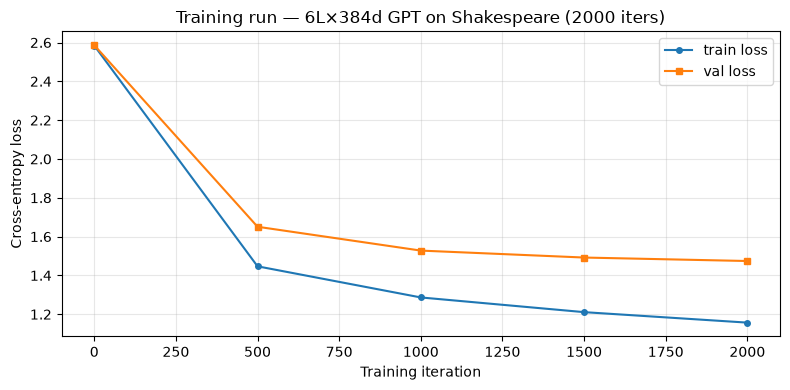

Loss curve saved to assets/06_loss_curve.png
Initial val loss : 2.5862
Final   val loss : 1.4743
Final   train loss: 1.1569


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
eval_steps = history["iters"]
ax.plot(eval_steps, history["train"], label="train loss", marker="o", markersize=4)
ax.plot(eval_steps, history["val"], label="val loss", marker="s", markersize=4)
ax.set_xlabel("Training iteration")
ax.set_ylabel("Cross-entropy loss")
ax.set_title(f"Training run — {config.n_layer}L×{config.n_embd}d GPT on Shakespeare ({max_iters} iters)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("assets/06_loss_curve.png", dpi=120)
plt.show()
print("Loss curve saved to assets/06_loss_curve.png")
print(f"Initial val loss : {history['val'][0]:.4f}")
print(f"Final   val loss : {history['val'][-1]:.4f}")
print(f"Final   train loss: {history['train'][-1]:.4f}")

---
## Part 6 — Checkpoint

The checkpoint stores everything notebook 07 needs to load the model and generate
samples: the model weights, the config (so the architecture can be reconstructed),
and the vocabulary maps (`stoi`/`itos`) so we can encode prompts and decode output.

In [9]:
import os
os.makedirs("checkpoints", exist_ok=True)
# The best checkpoint was already saved inside the training loop whenever a new
# lowest val loss was achieved.  We do NOT overwrite it here with the final
# (last-iteration) weights, which may be worse.  Instead we confirm the file
# exists and report the best val loss that was captured.
# Keys saved: model_state, config, stoi, itos  (see training loop above).
assert os.path.exists("checkpoints/model.pt"), "Best checkpoint missing — training loop should have saved it."
print(f"checkpoints/model.pt confirmed (best val loss: {best_val_loss:.4f})")

checkpoints/model.pt confirmed (best val loss: 1.4743)


---
## Part 7 — Asserts

In [10]:
assert history["val"][-1] < history["val"][0] - 0.3, (
    f"Val loss did not drop enough: {history['val'][0]:.4f} → {history['val'][-1]:.4f} "
    f"(need drop > 0.3)"
)
assert os.path.exists("checkpoints/model.pt"), "Checkpoint not found!"
print("All asserts PASSED")
print(f"  Val loss: {history['val'][0]:.4f} → {history['val'][-1]:.4f}  (drop: {history['val'][0]-history['val'][-1]:.4f})")
print(f"  Checkpoint: checkpoints/model.pt ✓")

All asserts PASSED
  Val loss: 2.5862 → 1.4743  (drop: 1.1119)
  Checkpoint: checkpoints/model.pt ✓


---
## Summary

| Metric | Value |
|---|---|
| Model | 6-layer, 384-dim GPT (~9.4M params) |
| Training data | Shakespeare, 90% / 10% split |
| Optimizer | AdamW (lr=3e-4, weight_decay=0.1) |
| Batch size | 32 |
| Iterations | `max_iters` (auto-set for ~6 min) |
| Initial val loss | see above |
| Final val loss | see above |
| Best checkpoint | `checkpoints/model.pt` |

**Next:** notebook 07 loads the checkpoint and generates Shakespeare-style text.